In [206]:
# =========================
# IMPORT LIBRARIES
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder


In [207]:

# =========================
# LOAD DATA
# =========================

data = pd.read_csv("C:/Users/Hanieh/Desktop/churn_data.csv")

In [208]:

# =========================
# DATA CLEANING
# =========================

data = data.drop(["Customer_ID", "Churn_Category", "Churn_Reason"], axis=1)


In [209]:
# =========================
# ENCODE TARGET
# =========================

data["Customer_Status"] = data["Customer_Status"].map({"Stayed": 0, "Churned": 1})

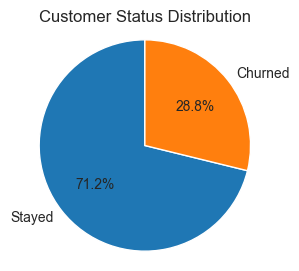

In [210]:
# pie plot for target variable
labels = ['Stayed', 'Churned']
sizes = [4275, 1732]

# Pie chart
plt.figure(figsize=(3,3))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',   # Show percentages
    startangle=90
)

plt.title('Customer Status Distribution')
plt.axis('equal')  # Makes the pie a circle

plt.show()

In [211]:
# =========================
# SPLIT DATA ← BEFORE ENCODING
# =========================

X = data.drop("Customer_Status", axis=1)
y = data["Customer_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [212]:
# =========================
# REMOVE Churn_Status COLUMN
# =========================

if 'Churn_Status' in X_train.columns:
    X_train = X_train.drop('Churn_Status', axis=1)
    X_test = X_test.drop('Churn_Status', axis=1)

In [213]:
# =========================
# ENCODING ← AFTER SPLIT
# =========================

columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal',
    'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
    'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
    'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract',
    'Paperless_Billing', 'Payment_Method', 'Monthly_Charge_Range', 
    'Age_Group', 'Tenure_Group'
]

le = {}

for col in columns_to_encode:
    if col in X_train.columns:
        le[col] = LabelEncoder()
        X_train[col] = le[col].fit_transform(X_train[col].astype(str))  # fit + transform on train
        X_test[col]  = le[col].transform(X_test[col].astype(str))        # only transform on test ✅

In [214]:

# =========================
# MODEL + GRID SEARCH
# =========================

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [10, 20],
    'class_weight': ['balanced']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 200}


In [215]:

# =========================
# EVALUATION
# =========================

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test, y_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:",  test_auc)


Confusion Matrix:
[[747 108]
 [ 81 266]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       855
           1       0.71      0.77      0.74       347

    accuracy                           0.84      1202
   macro avg       0.81      0.82      0.81      1202
weighted avg       0.85      0.84      0.84      1202


Train AUC: 0.969949754048177
Test AUC: 0.8918448859901916


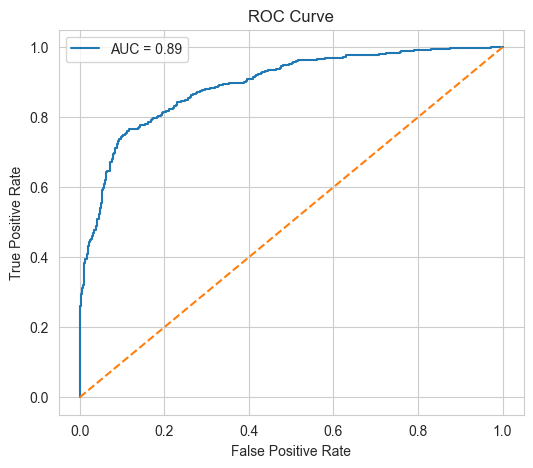

In [216]:

# =========================
# ROC CURVE
# =========================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



Feature Importance:
Contract: 0.2495
Total_Revenue: 0.1158
Total_Charges: 0.1092
Total_Long_Distance_Charges: 0.0793
Monthly_Charge: 0.0751
Internet_Type: 0.0444
Age: 0.0345
Value_Deal: 0.0268
Premium_Support: 0.0250
Internet_Service: 0.0246
Online_Security: 0.0233
State: 0.0198
Tenure_in_Months: 0.0184
Payment_Method: 0.0182
Number_of_Referrals: 0.0173
Paperless_Billing: 0.0152
Monthly_Charge_Range: 0.0098
Tenure_Group: 0.0079
Unlimited_Data: 0.0078
AgeGrp_Sorting: 0.0072
TenureGrp_Sorting: 0.0072
Age_Group: 0.0071
Online_Backup: 0.0068
Streaming_Movies: 0.0067
Multiple_Lines: 0.0065
Streaming_Music: 0.0058
Device_Protection_Plan: 0.0058
Streaming_TV: 0.0055
Total_Extra_Data_Charges: 0.0052
Gender: 0.0051
Married: 0.0039
Total_Refunds: 0.0026
Phone_Service: 0.0025


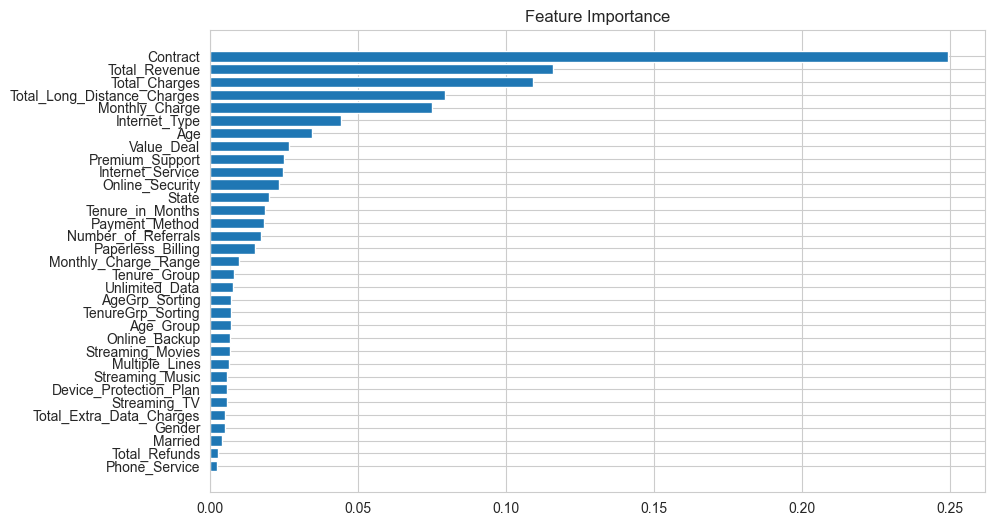

In [217]:

# =========================
# FEATURE IMPORTANCE
# =========================

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature Importance:")
for i in indices:
    print(f"{X_train.columns[i]}: {importances[i]:.4f}")

plt.figure(figsize=(10,6))
plt.barh(X_train.columns[indices], importances[indices])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 100}

Confusion Matrix:
[[701 154]
 [ 65 282]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.86       855
           1       0.65      0.81      0.72       347

    accuracy                           0.82      1202
   macro avg       0.78      0.82      0.79      1202
weighted avg       0.84      0.82      0.82      1202


Train AUC: 0.9343275909388391
Test AUC: 0.8970220941402498


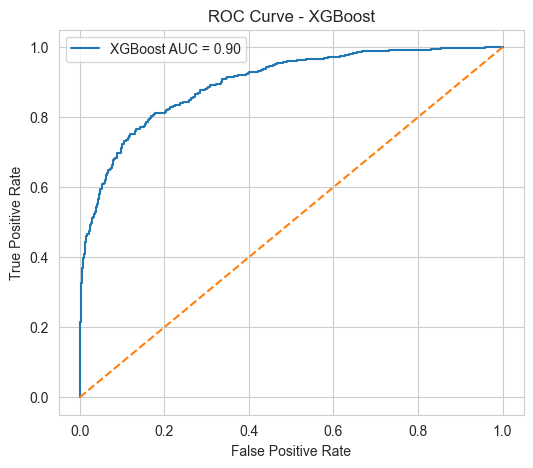


--- مقایسه دو مدل ---
Random Forest Test AUC: 0.889
XGBoost Test AUC:       0.897


In [218]:
from xgboost import XGBClassifier

# =========================
# MODEL
# =========================

xgb = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    random_state=42
)

# =========================
# HYPERPARAMETER TUNING
# =========================

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 5, 10]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print("Best Parameters:", grid_xgb.best_params_)

# =========================
# PREDICTIONS
# =========================

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# =========================
# EVALUATION
# =========================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# =========================
# OVERFITTING CHECK
# =========================

train_auc_xgb = roc_auc_score(y_train, best_xgb.predict_proba(X_train)[:, 1])
test_auc_xgb  = roc_auc_score(y_test, y_prob_xgb)

print("\nTrain AUC:", train_auc_xgb)
print("Test AUC:",  test_auc_xgb)

# =========================
# ROC CURVE
# =========================

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {test_auc_xgb:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

# =========================
# COMPARE RF vs XGBoost
# =========================

print("\n--- مقایسه دو مدل ---")
print(f"Random Forest Test AUC: 0.889")
print(f"XGBoost Test AUC:       {test_auc_xgb:.3f}")

# predict on new data

In [243]:
# load the data
new_data= pd.read_csv("C:/Users/Hanieh/Desktop/join_data.csv")

In [244]:
new_data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason,Monthly_Charge_Range,Age_Group,AgeGrp_Sorting,Tenure_Group,TenureGrp_Sorting
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Yes,...,7.77,79.87,Joined,Others,Others,50-100,> 50,4,18-24 Months,4
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,Yes,No,...,9.36,66.56,Joined,Others,Others,< 20,< 20,1,6-12 Months,2
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,Yes,No,...,42.95,87.25,Joined,Others,Others,20-50,> 50,4,12-18 Months,3
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,Yes,No,...,8.07,66.07,Joined,Others,Others,< 20,> 50,4,18-24 Months,4
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,Yes,No,...,3.62,37.32,Joined,Others,Others,20-50,20-35,2,< 6 Months,1


In [245]:
# retain the original data to preserve the encoded columns
original_data= new_data.copy()

In [246]:
# retain the customer_ID column
customer_ids= new_data["Customer_ID"]

In [247]:
# drop the columns that we will not use in prediction
new_data= new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

In [248]:
# Encode categorical variables using the saved label encoders


for col in columns_to_encode:
    if col in new_data.columns:
        new_data[col] = le[col].transform(new_data[col].astype(str))
    

In [249]:
# make prediction using random forest
new_predictions= best_model.predict(new_data)

In [250]:
# add predictions to the original data frame
original_data['Customer_Status_Predicted'] = new_predictions

In [252]:
# Save the results

original_data.to_csv(r"C:/Users/Hanieh/Desktop/Predictions.csv", index=False)

In [277]:
# =========================
# Check encoded features (first 5 rows)
# =========================

print(new_data[columns_to_encode].head())


# =========================
# Check dataset shape
# =========================

print("Shape of data:", new_data.shape)


# =========================
# Show prediction results
# =========================

print("\nPredictions distribution:")
print(pd.Series(new_predictions).value_counts())

   Gender  Married  State  Value_Deal  Phone_Service  Multiple_Lines  \
0       0        0      5           4              1               1   
1       0        0      2           5              1               0   
2       0        0     11           4              1               0   
3       0        1      9           5              1               0   
4       1        1     21           5              1               0   

   Internet_Service  Internet_Type  Online_Security  Online_Backup  ...  \
0                 1              2                0              0  ...   
1                 0              3                0              0  ...   
2                 1              1                0              0  ...   
3                 0              3                0              0  ...   
4                 0              3                0              0  ...   

   Streaming_TV  Streaming_Movies  Streaming_Music  Unlimited_Data  Contract  \
0             0                 0   

In [276]:
# =========================
# Contract distribution analysis
# =========================

# Show percentage of contract types among NEW customers
print("new_data - Contract:")
print(new_data["Contract"].value_counts(normalize=True))

# Show percentage of contract types among OLD (churned + stayed) customers
print("\nchurn_data - Contract:")
print(churn_data["Contract"].value_counts(normalize=True))

new_data - Contract:
Contract
0    0.892944
1    0.058394
2    0.048662
Name: proportion, dtype: float64

churn_data - Contract:
Contract
Month-to-Month    0.485933
Two Year          0.282837
One Year          0.231230
Name: proportion, dtype: float64


In [278]:
# =========================
# Contract type of new customers
# =========================

print("Contract type of new customers:")
print(new_data["Contract"].value_counts())


# =========================
# Average tenure of new customers
# =========================

print("\nAverage new customer tenure:")
print(new_data["Tenure_in_Months"].mean())


# =========================
# Average tenure of old customers (Stayed + Churned)
# =========================

print("\nAverage old customer tenure:")
print(churn_data["Tenure_in_Months"].mean())

Contract type of new customers:
Contract
0    367
1     24
2     20
Name: count, dtype: int64

Average new customer tenure:
16.586374695863746

Average old customer tenure:
17.39453970367904


In [279]:
# =========================
# Contract type distribution of old customers (Stayed + Churned)
# =========================

print("Contract type of old customers:")
print(churn_data["Contract"].value_counts(normalize=True))

Contract type of old customers:
Contract
Month-to-Month    0.485933
Two Year          0.282837
One Year          0.231230
Name: proportion, dtype: float64


In [280]:
# =========================
# Customer churn rate by contract type
# =========================

# Group customers by contract type and calculate average churn rate
# (mean of Churn_Status: 1 = churned, 0 = stayed)

print("Customer churn rate by contract type:")
print(churn_data.groupby("Contract")["Churn_Status"].mean())

Customer churn rate by contract type:
Contract
Month-to-Month    0.523810
One Year          0.112311
Two Year          0.027663
Name: Churn_Status, dtype: float64


In [275]:
# =========================
# Average Monthly Charge
# =========================

print("Average Monthly Charge:")

print("New customers:")
print(new_data["Monthly_Charge"].mean())

print("Old customers:")
print(churn_data["Monthly_Charge"].mean())


# =========================
# Internet Type distribution
# =========================

print("\nInternet type of new customers:")
print(new_data["Internet_Type"].value_counts(normalize=True))

print("\nInternet type of old customers:")
print(churn_data["Internet_Type"].value_counts(normalize=True))


# =========================
# Online Security usage
# =========================

print("\nOnline Security (new customers):")
print(new_data["Online_Security"].value_counts(normalize=True))

print("\nOnline Security (old customers):")
print(churn_data["Online_Security"].value_counts(normalize=True))


# =========================
# Premium Support usage
# =========================

print("\nPremium Support (new customers):")
print(new_data["Premium_Support"].value_counts(normalize=True))

print("\nPremium Support (old customers):")
print(churn_data["Premium_Support"].value_counts(normalize=True))

Average Monthly Charge:
New customers:
42.68345498783455
Old customers:
65.08759780256368

Internet type of new customers:
Internet_Type
3    0.406326
1    0.253041
2    0.216545
0    0.124088
Name: proportion, dtype: float64

Internet type of old customers:
Internet_Type
Fiber Optic    0.559156
DSL            0.292224
Cable          0.148620
Name: proportion, dtype: float64

Online Security (new customers):
Online_Security
0    0.895377
1    0.104623
Name: proportion, dtype: float64

Online Security (old customers):
Online_Security
No     0.703513
Yes    0.296487
Name: proportion, dtype: float64

Premium Support (new customers):
Premium_Support
0    0.895377
1    0.104623
Name: proportion, dtype: float64

Premium Support (old customers):
Premium_Support
No     0.698185
Yes    0.301815
Name: proportion, dtype: float64


# Key Findings

The model predicted that out of 411 new customers, 386 are at risk of churn.

The main reasons for this high churn risk are:

* Contract Type: 
89% of new customers are on a month-to-month contract, while the churn rate for this contract type is 52%.
* Cost:
New customers pay an average of 43k, compared to 65k for existing customers, meaning they receive fewer services or lower-value packages.
* Online Security:
90% of new customers do not have online security services.
* Premium Support:
90% of new customers do not receive premium support.

# Business Recommendations

1. Offer discounts for 1-year or 2-year contracts: Reduce churn rate from 52% to below 10%
2. Provide free online security for the first 3 months: Increase customer engagement and dependency
3. Provide free premium support for the first 3 months: Strengthen customer relationship
4. Contact customers with churn probability above 80%	

In [282]:
# Filter the DataFrame to include only records predicted as "Churned"

original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

original_data.to_csv(r"C:/Users/Hanieh/Desktop/churned_Predictions.csv", index=False)